# **Прогноз спроса BikeSouth нелинейные модели**

- Автор: Розова Ольга
- Дата: 01.06.2026 - 07.06.2026

**Цель:** Разработать нелинейную модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов, которая будет точнее используемой компанией BikeSouth линейной регрессии.

**Задачи:**
<ol>
  <li>Подготовка среды и библиотек.</li>
  <li>Изучить baseline-модель — загрузить готовый пайплайн с линейной регрессией и оценить её качество (RMSE, MAE, R²).</li>
  <li>Провести исследовательский анализ данных (EDA) и выявить факторы, влияющие на спрос.</li>    
  <li>Обучить модели kNN и Decision Tree Regressor.</li>
  <li>Оптимизировать гиперпараметры для обеих моделей с помощью Optuna (целевая метрика — RMSE).</li>
  <li>Сравнить модели между собой и с линейной регрессией по трём метрикам: RMSE, MAE, R².</li> 
  <li>Выбрать лучшую модель и один раз проверить её на тестовой выборке.</li>
  <li>Проанализировать важность признаков и сделать выводы с рекомендациями для бизнеса.</li>
</ol>

**Ключевые метрики:** 
<ol>
  <li>RMSE — основная метрика качества, используемая для выбора модели.</li>
  <li>MAE — средняя абсолютная ошибка прогноза.</li>
  <li>R² — доля объяснённой моделью вариации целевой переменной.</li>
</ol>

**Ожидаемый результат:** Получить модель, которая обеспечивает более точный прогноз почасового спроса на аренду велосипедов по сравнению с линейной регрессией и может быть использована для повышения эффективности логистики BikeSouth.

**Важно:** Для Optuna будем использовать neg_root_mean_squared_error (отрицательный RMSE), потому что cross_val_score работает по принципу «чем выше, тем лучше».

---

## Подготовка среды и библиотек

### Импортирт библиотек

Импортируем все необходимые библиотеки. Загрузим текстовый файл requirements.txt со списком библиотек и их версий. 

Установлено по requirements.txt, которые предоставляли в треде модуля. 

In [1]:
%%writefile requirements.txt
pandas==2.3.3
numpy==1.26.4
matplotlib==3.7.3
seaborn==0.13.2
phik==0.12.5
scikit-learn==1.6.1
optuna==4.8.0
joblib==1.5.3 

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt -q

In [3]:
# Работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn (используются следующие модули)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Optuna
import optuna

# Joblib
import joblib

# Встроенные библиотеки (из стандартной библиотеки Python, не требуют установки)
import warnings

###  Фиксация констант

In [4]:
# Константы проекта
RANDOM_STATE = 42
CV_FOLDS = 5
TARGET = 'rented_bike_count'
METRIC_RMSE = 'neg_root_mean_squared_error'
METRIC_MAE = 'neg_mean_absolute_error'

# Настройка стиля графиков
sns.set_style('whitegrid')

### Загрузка и первичная оценка всех данных

Загрузим датасеты, выведим характеристики: размер, первые несколько строк и информацию о типах столбцов.

In [5]:
# Определяем файлы для загрузки
files = ['_train_data.csv', '_test_data.csv']

# Загружаем файлы с обработкой разных путей
for file in files:
    try:
        df = pd.read_csv(f'/.../{file}')
        path = '/.../'
    except:
        df = pd.read_csv(file)
    
    name = file.replace('.csv', '').replace('ds_s14_', '')
    
    # Сохраняем в переменные по имени
    if name == 'train_data':
        train_data = df
    elif name == 'test_data':
        test_data = df

In [6]:
# Смотрим первые 5 строк train_data
print(f"\n{'='*40} \nТРЕНИРОВОЧНЫЕ ДАННЫЕ (первые 5 строк):\n{'='*40}")
display(train_data.head())


ТРЕНИРОВОЧНЫЕ ДАННЫЕ (первые 5 строк):


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [7]:
# Смотрим первые 5 строк test_data
print(f"\n{'='*40} \nТЕСТОВЫЕ ДАННЫЕ (первые 5 строк):\n{'='*40}")
display(test_data.head())


ТЕСТОВЫЕ ДАННЫЕ (первые 5 строк):


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


In [8]:
# Дополнительно: базовая информация
print(f"\n{'='*40} \nИНФОРМАЦИЯ О ДАННЫХ:\n{'='*40}")
print(f"\nTrain data: {train_data.shape[0]} строк, {train_data.shape[1]} столбцов")
print(f"Test data: {test_data.shape[0]} строк, {test_data.shape[1]} столбцов")


ИНФОРМАЦИЯ О ДАННЫХ:

Train data: 7008 строк, 16 столбцов
Test data: 1752 строк, 16 столбцов


In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [10]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

In [11]:
# Проверяем полные дубликаты в датафреймах
print(f"\n{'='*40} \nПРОВЕРКА ДУБЛИКАТОВ:\n{'='*40}")

train_duplicates = train_data.duplicated().sum()
test_duplicates = test_data.duplicated().sum()

print(f"Дубликаты в train_data: {train_duplicates}")
print(f"Дубликаты в test_data: {test_duplicates}")


ПРОВЕРКА ДУБЛИКАТОВ:
Дубликаты в train_data: 0
Дубликаты в test_data: 0


In [12]:
# Проверяем неявные дубликаты в датафрейме df
categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']

for col in categorical_cols:
    print(f"\n{'=' * 50}")
    print(f"Уникальные значения в столбце '{col}':")
    print(f"Всего уникальных значений в train: {train_data[col].nunique()}")
    print(f"Всего уникальных значений в test: {test_data[col].nunique()}")
    print(f"{'=' * 50}")

    # Объединяем уникальные значения из train и test
    unique_vals = set(train_data[col].dropna().unique()) | set(test_data[col].dropna().unique())

    for i, val in enumerate(sorted(unique_vals), 1):
        print(f"{i:3}. {val}")


Уникальные значения в столбце 'Seasons':
Всего уникальных значений в train: 4
Всего уникальных значений в test: 4
  1. Autumn
  2. Spring
  3. Summer
  4. Winter

Уникальные значения в столбце 'Holiday':
Всего уникальных значений в train: 2
Всего уникальных значений в test: 2
  1. Holiday
  2. No Holiday

Уникальные значения в столбце 'Functioning Day':
Всего уникальных значений в train: 2
Всего уникальных значений в test: 2
  1. No
  2. Yes


In [13]:
for name, df in [('TRAIN_DATA', train_data), ('TEST_DATA', test_data)]:
    print(f"\n{'=' * 50}")
    print(f"АНАЛИЗ ПРОПУСКОВ В {name}:")
    print('=' * 50)

    missing = df.isna().sum()
    result = pd.DataFrame({
        'Количество пропусков': missing,
        'Доля (%)': (missing / len(df) * 100).round(2)
    })

    print(result[result['Количество пропусков'] > 0])


АНАЛИЗ ПРОПУСКОВ В TRAIN_DATA:
                         Количество пропусков  Доля (%)
Humidity(%)                               250      3.57
Wind speed (m/s)                          210      3.00
Visibility (10m)                          259      3.70
Solar Radiation (MJ/m2)                   210      3.00
Rainfall(mm)                              262      3.74
Snowfall (cm)                             263      3.75

АНАЛИЗ ПРОПУСКОВ В TEST_DATA:
                         Количество пропусков  Доля (%)
Humidity(%)                                72      4.11
Wind speed (m/s)                           52      2.97
Visibility (10m)                           72      4.11
Solar Radiation (MJ/m2)                    52      2.97
Rainfall(mm)                               64      3.65
Snowfall (cm)                              61      3.48


Установлены и загружены библиотеки. Загрузка данных выполнена успешно. 

Данные:
- Датасет `ds_s14_train_data.csv` содержит **7008 строк и 16 столбцов**, предназначен для обучения и валидации модели.
- Датасет `ds_s14_test_data.csv` содержит **1752 строк и 16 столбцов**, предназначен для финальной проверки модели.
- Названия столбцов во всех датасетах **не соотвествуют `snake case`**.
- Значения в столбцах соответствуют описанию.
- Явных дубликатов (`duplicated()`) не обнаружено.
- Неявных дубликатов в категориальных признаках (`Seasons`, `Holiday`, `Functioning Day`) не выявлено: различия в регистре, написании и лишних пробелах отсутствуют.
- Категориальные признаки содержат одинаковые наборы значений в обучающей и тестовой выборках, что исключает проблемы при кодировании категорий.
- В данных присутствуют пропуски.

Анализ пропусков:
- Пропуски обнаружены только в числовых признаках:

| Признак	                |Train (%)|Test (%)|
|---------------------------|---------|--------|
|Humidity(%)	            |  3.57   |  4.11  |
|Wind speed (m/s)       	|  3.00   |  2.97  |
|Visibility (10m)	        |  3.70   |  4.11  |
|Solar Radiation (MJ/m2)	|  3.00   |  2.97  |
|Rainfall(mm)           	|  3.74   |  3.65  |
|Snowfall (cm)          	|  3.75   |  3.48  |

- Доля пропусков во всех признаках не превышает 5%.
- Распределение пропусков в обучающей и тестовой выборках практически одинаково.
- Массового отсутствия данных не наблюдается, поэтому удаление строк не требуется.
- Перед обучением модели необходимо выполнить обработку пропусков (например, заполнение медианными значениями или использование встроенных механизмов обработки пропусков в выбранном алгоритме).

Что нужно сделать перед использованием модели:
- Привести названия столбцов к стилю snake_case.
- Проверить совпадение состава и порядка признаков в обучающей и тестовой выборках.
- Выполнить обработку пропущенных значений.
- Закодировать категориальные признаки или использовать модель, поддерживающую работу с категориальными данными.
- Убедиться, что категориальные значения в тестовой выборке совпадают со значениями, использованными при обучении модели.
- При необходимости выполнить масштабирование числовых признаков (если этого требует выбранный алгоритм).

**Вывод:** данные имеют хорошее качество: дубликаты отсутствуют, категориальные признаки согласованы между выборками, а количество пропусков невелико и может быть обработано стандартными методами предобработки. Это позволяет использовать датасеты для дальнейшего построения и оценки моделей машинного обучения.

---

## Обучение и оценка базовой модели

Загрузим `.joblib файл`. Приведем названия колонок к тому виду, который ожидает модель. Убедимся, что набор признаков совпадает. Проверим, что категориальные значения соответствуют тем, что были при обучении. Разделим тестовый набор на признаки (X) и целевую переменную `Rented Bike Count`. Посчитаем `RMSE`, `MAE` и `R²`, эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

### Загрузка базовой модели

In [14]:
# Загрузка модели
with open('/../...joblib', 'rb') as file:
    baseline_model = joblib.load(file)
    
# После загрузки
print(type(baseline_model))
print(baseline_model)    

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_temperature',
                                                   'solar_radiation_mjm2',
                                                   'rainfallmm',
                                                   'snowfall_cm']),
                              

### Первичная предобработка данных

In [15]:
# Переименовываем колонки в snake_case (как ожидает модель)
rename_dict = {
    'Temperature': 'temperature',
    'Humidity(%)': 'humidity',
    'Wind speed (m/s)': 'wind_speed_ms',
    'Visibility (10m)': 'visibility_10m',
    'Dew point temperature': 'dew_point_temperature',
    'Solar Radiation (MJ/m2)': 'solar_radiation_mjm2',
    'Rainfall(mm)': 'rainfallmm',
    'Snowfall (cm)': 'snowfall_cm',
    'Seasons': 'seasons',
    'Holiday': 'holiday',
    'Functioning Day': 'functioning_day',
    'Time_Period_Evening': 'time_period_evening',
    'Time_Period_Late Evening': 'time_period_late_evening',
    'Time_Period_Morning': 'time_period_morning',
    'Time_Period_Night': 'time_period_night',
    'Rented Bike Count': 'rented_bike_count'
}

train_data = train_data.rename(columns=rename_dict)
test_data = test_data.rename(columns=rename_dict)

In [16]:
# Разделяем train_data на обучение (80%) и валидацию (20%)
# stratify не используем, т.к. это регрессия
X = train_data.drop(columns=[TARGET])
y = train_data[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    shuffle=True
)

print(f"\nРазмеры выборок:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")


Размеры выборок:
X_train: (5606, 15)
X_val:   (1402, 15)
y_train: (5606,)
y_val:   (1402,)


In [17]:
# Проверяем, какие признаки ожидает baseline-модель
# Загружаем модель и смотрим её структуру

# Получаем ожидаемые признаки из модели
# Для Pipeline нужно залезть внутрь ColumnTransformer
preprocessor = baseline_model.named_steps['preprocessor']

# Собираем все ожидаемые признаки
expected_features = []

# 1. Числовые признаки
num_features = preprocessor.named_transformers_['num'].feature_names_in_
expected_features.extend(num_features)

# 2. Категориальные признаки
cat_features = preprocessor.named_transformers_['cat'].feature_names_in_
expected_features.extend(cat_features)

# 3. Временные признаки (из passthrough)
for name, transformer, columns in preprocessor.transformers_:
    if name == 'time':
        expected_features.extend(columns)

print("Ожидаемые признаки модели:")
print(expected_features)

print("\nФактические признаки в данных:")
actual_features = X_train.columns.tolist()
print(actual_features)

# Сравниваем
missing_in_data = set(expected_features) - set(actual_features)
extra_in_data = set(actual_features) - set(expected_features)

print(f"\nПризнаки, которые есть в модели, но нет в данных: {missing_in_data}")
print(f"Признаки, которые есть в данных, но не ожидает модель: {extra_in_data}")

# Если всё ок
if not missing_in_data:
    print("Все ожидаемые признаки присутствуют в данных!")

Ожидаемые признаки модели:
['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm', 'seasons', 'holiday', 'functioning_day', 'time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']

Фактические признаки в данных:
['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm', 'seasons', 'holiday', 'functioning_day', 'time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']

Признаки, которые есть в модели, но нет в данных: set()
Признаки, которые есть в данных, но не ожидает модель: set()
Все ожидаемые признаки присутствуют в данных!


### Предсказание и метрики

In [18]:
# Предсказание и метрики
y_pred = baseline_model.predict(X_train)

# Запуск модели на обучающей выборке
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"\n{'='*40} \nBaseline Linear Regression:\n{'='*40}")
print(f"\nОценка на обучении:")
print(f"{'-'*40}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

y_pred_val = baseline_model.predict(X_val)
# Запуск модели на валидационной выборке
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val = mean_absolute_error(y_val, y_pred_val)
r2_val = r2_score(y_val, y_pred_val)
    
print(f"\nОценка на валидации:")
print(f"{'-'*40}")
print(f"RMSE: {rmse_val:.2f}")
print(f"MAE:  {mae_val:.2f}")
print(f"R²:   {r2_val:.4f}")


Baseline Linear Regression:

Оценка на обучении:
----------------------------------------
RMSE: 412.61
MAE: 308.54
R²: 0.5934

Оценка на валидации:
----------------------------------------
RMSE: 412.04
MAE:  311.62
R²:   0.5893


Модель стабильна, переобучения нет. Но качество невысокое — R² ≈ 0.59 означает, что модель объясняет только 59% дисперсии спроса. 41% остаётся необъяснённым — это пространство для улучшения.

In [19]:
# Оценим Baseline на тестовой выборке
print(f"\nОценка на тестовой выборке:")
print(f"{'-'*40}")

# Подготавливаем тестовые данные (приводим к нужным названиям колонок)
X_test_full = test_data.drop(columns=[TARGET])
y_test_full = test_data[TARGET]

y_pred_test_baseline = baseline_model.predict(X_test_full)

rmse_test_baseline = np.sqrt(mean_squared_error(y_test_full, y_pred_test_baseline))
mae_test_baseline = mean_absolute_error(y_test_full, y_pred_test_baseline)
r2_test_baseline = r2_score(y_test_full, y_pred_test_baseline)

print(f"RMSE: {rmse_test_baseline:.2f}")
print(f"MAE: {mae_test_baseline:.2f}")
print(f"R²: {r2_test_baseline:.4f}")

print(f"\nСравнение валидация vs тест:")
print(f"RMSE: {rmse_val:.2f} → {rmse_test_baseline:.2f} (разница: {abs(rmse_val - rmse_test_baseline):.2f})")
print(f"R²: {r2_val:.4f} → {r2_test_baseline:.4f}")


Оценка на тестовой выборке:
----------------------------------------
RMSE: 411.45
MAE: 312.53
R²: 0.5863

Сравнение валидация vs тест:
RMSE: 412.04 → 411.45 (разница: 0.59)
R²: 0.5893 → 0.5863


Baseline-модель показала стабильное качество на валидационной и тестовой выборках. Метрики RMSE (412.04 и 411.45) и R² (0.5893 и 0.5863) практически совпадают, что говорит об отсутствии переобучения и хорошей способности модели обобщать данные. 

---

## Исследовательский анализ данных (EDA)

Посмотрим на распределение целевой переменной `Rented Bike Count`: eсть ли выбросы или сильные сезонные колебания.

###  Распределение целевой переменной


ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: rented_bike_count, dtype: float64


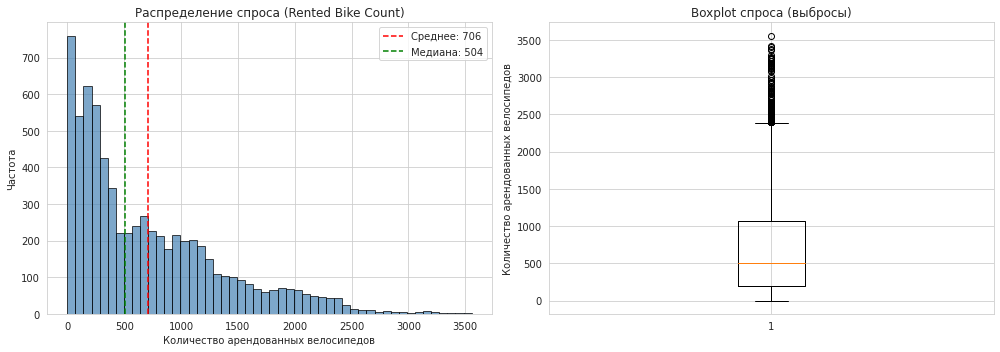

In [20]:
# Описательная статистика
print(f"\n{'='*50} \nОПИСАТЕЛЬНАЯ СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ\n{'='*50}")
print(train_data[TARGET].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(train_data[TARGET], bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_xlabel('Количество арендованных велосипедов')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение спроса (Rented Bike Count)')
axes[0].axvline(train_data[TARGET].mean(), color='red', linestyle='--', label=f'Среднее: {train_data[TARGET].mean():.0f}')
axes[0].axvline(train_data[TARGET].median(), color='green', linestyle='--', label=f'Медиана: {train_data[TARGET].median():.0f}')
axes[0].legend()

# Boxplot (для выбросов)
axes[1].boxplot(train_data[TARGET], vert=True)
axes[1].set_ylabel('Количество арендованных велосипедов')
axes[1].set_title('Boxplot спроса (выбросы)')

plt.tight_layout()
plt.show()

Распределение спроса имеет правосторонюю асимметрию (среднее > медианы). Это означает, что чаще всего спрос низкий или средний, но иногда бывают очень высокие пики (до 3556 велосипедов). Для модели это важно: она должна хорошо предсказывать как обычные дни, так и редкие всплески спроса. Линейная регрессия с этим справляется плохо.

### Зависимость спроса от температуры

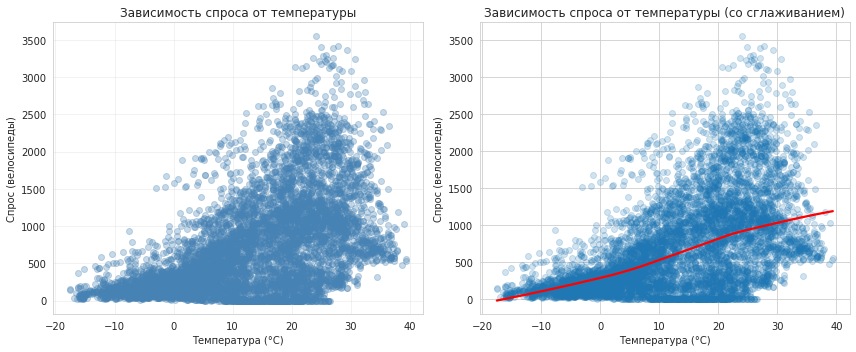


СПРОС ПО ТЕМПЕРАТУРНЫМ ИНТЕРВАЛАМ:
                     mean  count
temp_group                      
(-17.557, -11.81]   133.0     97
(-11.81, -6.12]     174.0    332
(-6.12, -0.43]      218.0    674
(-0.43, 5.26]       332.0    977
(5.26, 10.95]       535.0    990
(10.95, 16.64]      707.0    926
(16.64, 22.33]      909.0   1252
(22.33, 28.02]     1207.0   1077
(28.02, 33.71]     1201.0    554
(33.71, 39.4]       897.0    129


In [21]:
# Температура vs Спрос
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(train_data['temperature'], train_data[TARGET], alpha=0.3, color='steelblue')
plt.xlabel('Температура (°C)')
plt.ylabel('Спрос (велосипеды)')
plt.title('Зависимость спроса от температуры')
plt.grid(True, alpha=0.3)

# С добавлением сглаживания
plt.subplot(1, 2, 2)
sns.regplot(data=train_data, x='temperature', y=TARGET, lowess=True, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.xlabel('Температура (°C)')
plt.ylabel('Спрос (велосипеды)')
plt.title('Зависимость спроса от температуры (со сглаживанием)')

plt.tight_layout()
plt.show()

# Группировка по температурным интервалам
train_data['temp_group'] = pd.cut(train_data['temperature'], bins=10)
temp_analysis = (
    train_data
    .groupby('temp_group', observed=True)[TARGET]
    .agg(['mean', 'count'])
    .round(0)
)
print(f"\n{'='*50} \nСПРОС ПО ТЕМПЕРАТУРНЫМ ИНТЕРВАЛАМ:\n{'='*50}")
print(temp_analysis)

Зависимость нелинейная:
- при отрицательных температурах (зимой) спрос минимальный (~130-220 велосипедов)
- при температуре от 0°C до +10°C спрос растёт (~330-535)
- пик спроса при +22-28°C (~1200 велосипедов)
- при очень жаркой погоде (>33°C) спрос снова падает (~900)

### Зависимость спроса от погодных факторов

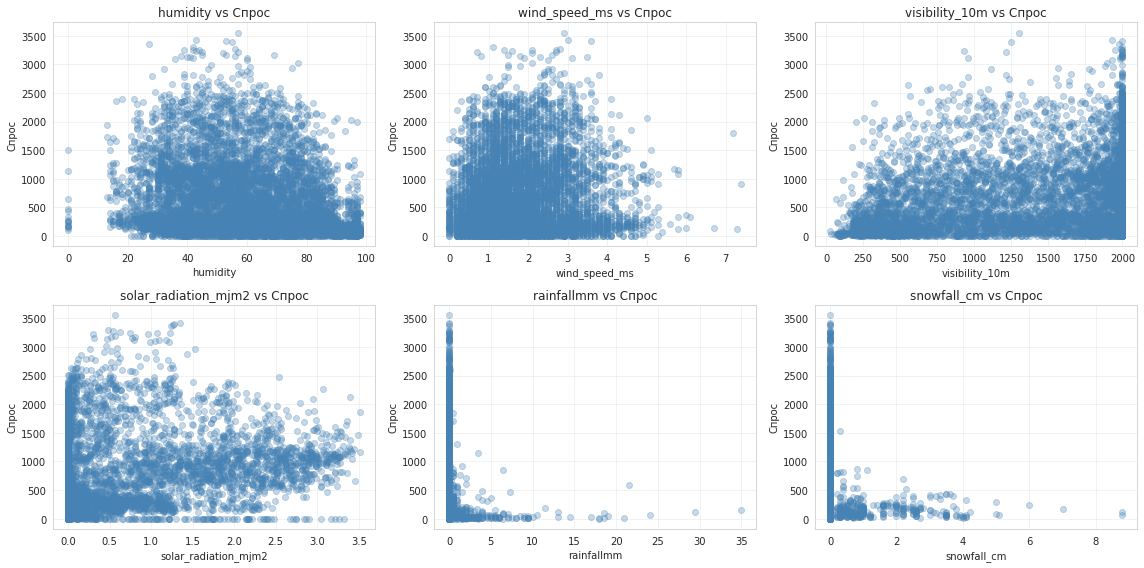

In [22]:
# Погодные факторы
weather_features = ['humidity', 'wind_speed_ms', 'visibility_10m', 
                    'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(weather_features):
    axes[i].scatter(train_data[feature], train_data[TARGET], alpha=0.3, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Спрос')
    axes[i].set_title(f'{feature} vs Спрос')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. Солнечная радиация — важный непрерывный признак. Чем больше солнца, тем выше спрос.
2. Дождь и снег — работают как "выключатели". Даже небольшое количество осадков резко снижает спрос.
3. Ветер важен только при сильных значениях (>6 м/с).
4. Влажность и видимость дают дополнительную информацию, но их вклад меньше.

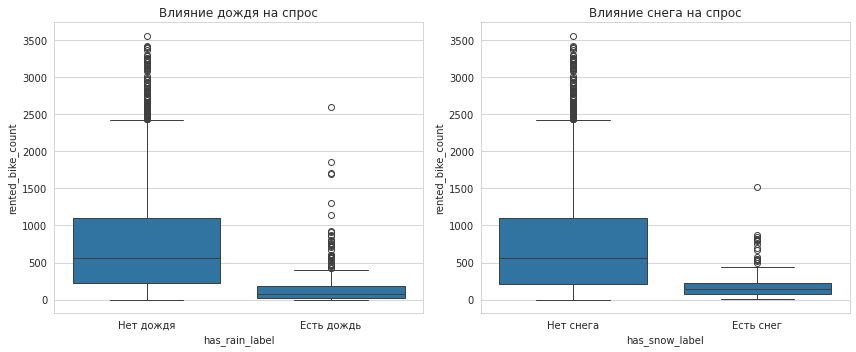

In [23]:
# Бинарные признаки наличия осадков
train_data['has_rain'] = (train_data['rainfallmm'] > 0).astype(int)
train_data['has_snow'] = (train_data['snowfall_cm'] > 0).astype(int)

# Подписи для графиков
train_data['has_rain_label'] = train_data['has_rain'].map({
    0: 'Нет дождя',
    1: 'Есть дождь'
})

train_data['has_snow_label'] = train_data['has_snow'].map({
    0: 'Нет снега',
    1: 'Есть снег'
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=train_data, x='has_rain_label', y=TARGET, ax=axes[0])
axes[0].set_title('Влияние дождя на спрос')

sns.boxplot(data=train_data, x='has_snow_label', y=TARGET, ax=axes[1])
axes[1].set_title('Влияние снега на спрос')

plt.tight_layout()
plt.show()

1. Дождь снижает спрос в 4-5 раз
   - При отсутствии дождя медиана спроса ~550-600 велосипедов
   - При дожде медиана падает до ~100-150
2. Снег снижает спрос ещё сильнее (в 7-10 раз)
   - При снеге медиана спроса составляет всего ~50-80 велосипедов

### Сравнение спроса по сезонам

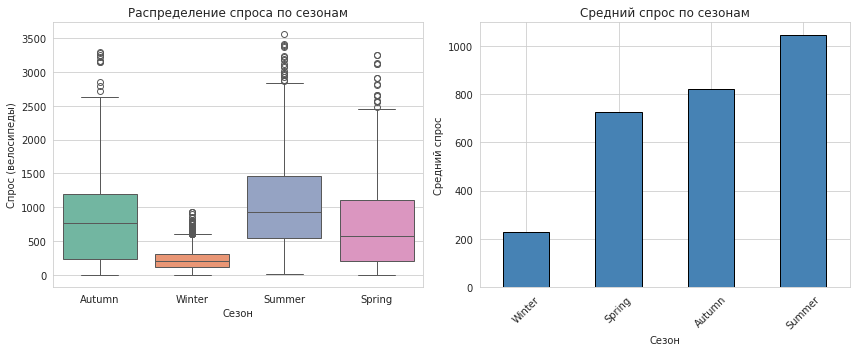


СРЕДНИЙ СПРОС ПО СЕЗОНАМ:
           mean  median  count
seasons                       
Summer   1046.0   923.0   1744
Autumn    821.0   764.0   1770
Spring    725.0   578.0   1758
Winter    226.0   204.0   1736


In [24]:
# Спрос по сезонам
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=train_data, x='seasons', y=TARGET, hue='seasons', palette='Set2', legend=False)

plt.xlabel('Сезон')
plt.ylabel('Спрос (велосипеды)')
plt.title('Распределение спроса по сезонам')

# Средний спрос по сезонам
plt.subplot(1, 2, 2)

season_mean = (train_data.groupby('seasons', observed=True)[TARGET].mean().sort_values())

season_mean.plot(kind='bar', color='steelblue', edgecolor='black')

plt.xlabel('Сезон')
plt.ylabel('Средний спрос')
plt.title('Средний спрос по сезонам')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Таблица статистик
print(f"\n{'='*50}")
print("СРЕДНИЙ СПРОС ПО СЕЗОНАМ:")
print(f"{'='*50}")

season_stats = (train_data.groupby('seasons', observed=True)[TARGET].agg(['mean', 'median', 'count']).round(0).sort_values('mean', ascending=False))

print(season_stats)

# Краткий вывод
best_season = season_stats.index[0]
worst_season = season_stats.index[-1]

Летом спрос в 4-5 раз выше, чем зимой. Это очень сильный фактор. Разброс значений (межквартильный размах на boxplot) летом тоже больше — значит, в тёплое время года спрос сильно зависит от других факторов (погода, время суток).

### Праздники vs Будни


СПРОС В ПРАЗДНИЧНЫЕ И БУДНИ:
             mean  median    std
holiday                         
Holiday     494.0   228.0  569.0
No Holiday  716.0   524.0  648.0


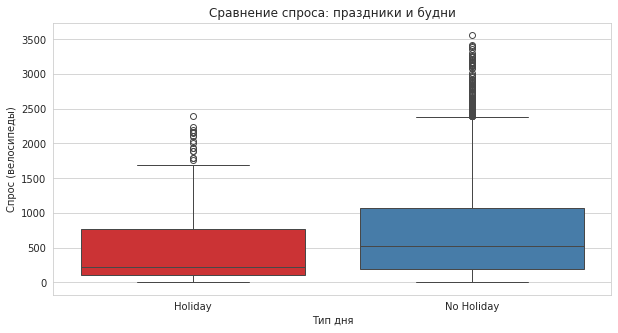

In [25]:
# Спрос в праздники и будни
plt.figure(figsize=(10, 5))

# Статистика
holiday_analysis = (
    train_data
    .groupby('holiday', observed=True)[TARGET]
    .agg(['mean', 'median', 'std'])
    .round(0)
)

print(f"\n{'='*50}")
print("СПРОС В ПРАЗДНИЧНЫЕ И БУДНИ:")
print(f"{'='*50}")
print(holiday_analysis)

# Визуализация
sns.boxplot(
    data=train_data,
    x='holiday',
    y=TARGET,
    hue='holiday',
    palette='Set1',
    legend=False
)

plt.xlabel('Тип дня')
plt.ylabel('Спрос (велосипеды)')
plt.title('Сравнение спроса: праздники и будни')
plt.show()

В праздники спрос НИЖЕ на ~30% (494 vs 716). Но разброс тоже большой — в праздники бывают как очень тихие дни, так и достаточно активные. Возможно, нужно учитывать тип праздника (новогодние каникулы vs майские праздники), но в данных этой информации нет.


АНАЛИЗ ПРИЗНАКА FUNCTIONING DAY:
Уникальные значения: ['Yes' 'No']

Строк с 'No' (сервис не работал): 242
Уникальные значения спроса: [0]
Вывод: при значении 'No' спрос всегда равен 0.
Признак содержит информацию о фактической работе сервиса и может приводить к утечке данных.


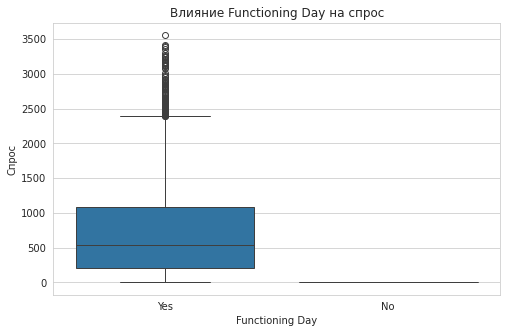


Распределение значений:
----------------------------------------
functioning_day
Yes    6766
No      242
Name: count, dtype: int64


array([0])

In [26]:
print("\n" + "="*50)
print("АНАЛИЗ ПРИЗНАКА FUNCTIONING DAY:")
print("="*50)

# Уникальные значения
print(f"Уникальные значения: {train_data['functioning_day'].unique()}")

# Когда сервис НЕ работал
not_functioning = train_data[train_data['functioning_day'] == 'No']
print(f"\nСтрок с 'No' (сервис не работал): {len(not_functioning)}")

if len(not_functioning) > 0:
    print(f"Уникальные значения спроса: {not_functioning[TARGET].unique()}")

    if (not_functioning[TARGET] == 0).all():
        print("Вывод: при значении 'No' спрос всегда равен 0.")
        print("Признак содержит информацию о фактической работе сервиса и может приводить к утечке данных.")
    else:
        print("Вывод: при значении 'No' встречаются ненулевые значения спроса.")

# Визуализация
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=train_data,
    x='functioning_day',
    y=TARGET
)
plt.xlabel('Functioning Day')
plt.ylabel('Спрос')
plt.title('Влияние Functioning Day на спрос')
plt.show()

print("\nРаспределение значений:")
print(f"{'-'*40}")
print(train_data['functioning_day'].value_counts())

train_data[train_data['functioning_day'] == 'No'][TARGET].unique()
# array([0])

In [27]:
not_working = train_data[train_data['functioning_day'] == 'No']

print("Количество дней, когда сервис не работал:")
print(f"{'-'*40}")
print(len(not_working))

print("\nСтатистика осадков:")
print(f"{'-'*40}")
print(
    not_working[['rainfallmm', 'snowfall_cm']]
    .describe()
)

print("\nДоля записей с дождем:")
print(f"{'-'*40}")
print((not_working['rainfallmm'] > 0).mean() * 100)

print("\nДоля записей со снегом:")
print(f"{'-'*40}")
print((not_working['snowfall_cm'] > 0).mean() * 100)

train_data.groupby('functioning_day')[['rainfallmm', 'snowfall_cm']].mean()

Количество дней, когда сервис не работал:
----------------------------------------
242

Статистика осадков:
----------------------------------------
       rainfallmm  snowfall_cm
count  234.000000        233.0
mean     0.105128          0.0
std      1.190401          0.0
min      0.000000          0.0
25%      0.000000          0.0
50%      0.000000          0.0
75%      0.000000          0.0
max     18.000000          0.0

Доля записей с дождем:
----------------------------------------
3.3057851239669422

Доля записей со снегом:
----------------------------------------
0.0


,rainfallmm,snowfall_cm
functioning_day,,
No,0.105128,0.000000
Yes,0.148403,0.077426


In [28]:
pd.crosstab(
    train_data['functioning_day'],
    train_data['seasons'],
    margins=True
)

seasons,Autumn,Spring,Summer,Winter,All
functioning_day,,,,,
No,201,41,0,0,242
Yes,1569,1717,1744,1736,6766
All,1770,1758,1744,1736,7008


Признак `functioning_day` содержит информацию о фактической работе сервиса и может приводить к утечке данных. Дополнительный анализ показал, что неработающие дни не связаны с осадками: снегопад в такие периоды отсутствует, а дождь наблюдается лишь в 3.3% случаев. Все закрытия сервиса приходятся на весну и осень. Признак `functioning_day` не описывает спрос напрямую, а определяет возможность его существования. При значении `No` спрос всегда равен нулю, поэтому влияние признака носит характер ограничивающего правила, а не статистической зависимости. Для корректной оценки спроса анализ следует проводить отдельно для дней, когда сервис работает. Необходимо отфильтровать по `Yes`, далее удаляем, т.к. не несет полезной информации для моделей.

### Корреляционный анализ

In [29]:
print("="*50)
print("КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ (Spearman)")
print("="*50)

numeric_features = [
    'temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
    'dew_point_temperature', 'solar_radiation_mjm2',
    'rainfallmm', 'snowfall_cm'
]

corr_target = (
    train_data[numeric_features + [TARGET]]
    .corr(method='spearman')[TARGET]
    .sort_values(ascending=False)
)

print(corr_target)

КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ (Spearman)
rented_bike_count        1.000000
temperature              0.566769
dew_point_temperature    0.381000
solar_radiation_mjm2     0.378548
visibility_10m           0.173862
wind_speed_ms            0.138510
humidity                -0.212000
snowfall_cm             -0.225100
rainfallmm              -0.273875
Name: rented_bike_count, dtype: float64


Спрос на велосипеды в большей степени зависит от погодных условий, особенно температуры.

In [30]:
print("\n" + "="*50)
print("МУЛЬТИКОЛЛИНЕАРНОСТЬ")
print("="*50)

corr_matrix = train_data[numeric_features].corr(method='spearman')

high_corr = (
    corr_matrix
    .where(lambda x: (x.abs() > 0.7) & (x != 1))
    .stack()
    .reset_index()
)

if len(high_corr) > 0:
    high_corr.columns = ['feature_1', 'feature_2', 'corr']
    print("Сильные корреляции (>0.7):")
    print(high_corr.drop_duplicates())
else:
    print("Сильной мультиколлинеарности нет.")


МУЛЬТИКОЛЛИНЕАРНОСТЬ
Сильные корреляции (>0.7):
               feature_1              feature_2      corr
0            temperature  dew_point_temperature  0.912951
1  dew_point_temperature            temperature  0.912951


Из-за высокой корреляции между температурой и точкой росы один из признаков может быть исключён для снижения мультиколлинеарности.

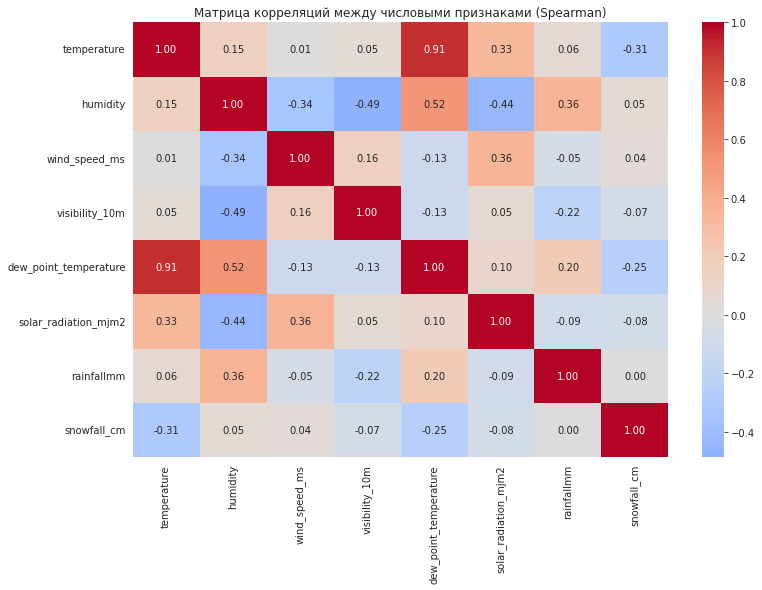

In [31]:
# Визуализация матрицы корреляций (Spearman)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций между числовыми признаками (Spearman)')
plt.show()

Анализ показал, что наибольшее влияние на спрос оказывает температура. Осадки (дождь и снег) и влажность снижают количество аренд. Обнаружена высокая корреляция между температурой и точкой росы, что указывает на наличие мультиколлинеарности. Для моделей на основе деревьев она не критична, однако kNN чувствителен к мультиколлинеарности и масштабированию. Поэтому `temperature` рекомендовано оставить, а `dew_point_temperature` - удалить.

In [32]:
# Удаляем временные колонки (has_rain, has_snow, temp_group) из train_data, чтобы они не попали в модели как признаки.
train_data = train_data.drop(columns=['has_rain', 'has_snow', 'temp_group'])

# Модель обучаем только на днях, когда сервис работает
train_data = train_data[train_data['functioning_day'] == 'Yes'].copy()
test_data = test_data[test_data['functioning_day'] == 'Yes'].copy()

# Удаляем сильно скоррелированный признак
train_data = train_data.drop(columns=['dew_point_temperature', 'functioning_day'], errors='ignore')
test_data = test_data.drop(columns=['dew_point_temperature', 'functioning_day'], errors='ignore')

**ВЫВОД:**

Заказчик утверждал: 
"Для нашей линейной модели +28°C под палящим солнцем и +28°C после дождя — это одно и то же, хотя это две большие разницы!"

**Заключение:** В ходе исследовательского анализа данных выявлены следующие закономерности:

Наиболее сильные предикторы спроса:
- Сезон — летом спрос в 4-5 раз выше, чем зимой (1046 vs 226 велосипедов)
- Температура — нелинейная зависимость с пиком при 22-28°C (корреляция Спирмена 0.567)
- Осадки — дождь снижает спрос в 4-5 раз, снег — в 7-10 раз
- Время суток — вечерний час пик (17:00-22:00) даёт максимальную нагрузку

Исключённые признаки и обоснование:
- `functioning_day` — датафреймы отфильтрованы по `Yes` (когда сервис работал), после удаляем - неиформативный столбец.
- `dew_point_temperature` — удалён из-за высокой мультиколлинеарности с температурой (корреляция 0.913), что критично для kNN

Низкие/средние значения линейной корреляции и явно выраженные нелинейные зависимости (температура, осадки) подтверждают гипотезу заказчика. Переход к нелинейным моделям (`kNN`, `ecision Tree`) должен дать существенное улучшение качества прогнозов по сравнению с линейной регрессией.

### Подготовка выборок

In [33]:
# Разделяем train_data на обучение (80%) и валидацию (20%)
# stratify не используем, т.к. это регрессия
X = train_data.drop(columns=[TARGET])
y = train_data[TARGET]

# Формирование тестовых данных
X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    shuffle=True
)

# Объединенние train + val
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

# Подготавливаем тестовые данные
X_test_full = test_data.drop(columns=[TARGET])
y_test_full = test_data[TARGET]


---

## Обучение модели kNN и Decision Tree Regressor.

### Предобработка данных (аналогично baseline)

In [34]:
# 1. Определяем группы признаков (как в baseline)
numeric_features = [
    'temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
    'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm'
]

categorical_features = ['seasons', 'holiday',
    'time_period_evening', 'time_period_late_evening',
    'time_period_morning', 'time_period_night'
]

# 2. Создаём трансформеры
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Собираем общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

### Пайплайн для KNN (базовые параметры)

In [35]:
# Базовые параметры KNN
# n_neighbors = 5 (стандартное значение)
# weights = 'uniform' (все соседи равны)
# p = 2 (евклидово расстояние)

model_knn = KNeighborsRegressor(
        n_neighbors=5,      # количество соседей
        weights='uniform',  # равный вес соседей
        p=2,                # евклидово расстояние
        n_jobs=-1           # используем все ядра
    )

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_knn)
])

### Пайплайн для Decision Tree Regressor

In [36]:
# Базовые параметры Decision Tree
# max_depth = None (без ограничения глубины)
# min_samples_split = 2 (стандарт)
# min_samples_leaf = 1 (стандарт)

model_tree = DecisionTreeRegressor(
        max_depth=None,          # без ограничения глубины
        min_samples_split=2,     # мин. объектов для разбиения
        min_samples_leaf=1,      # мин. объектов в листе
        random_state=RANDOM_STATE
    )

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_tree)
])

### Обучение (без оптимизации) и оценка качества (на валидации)

In [37]:
# Обучаем KNN
knn_pipeline.fit(X_train, y_train)

# Обучаем Decision Tree
tree_pipeline.fit(X_train, y_train)

print("Обе модели успешно обучены")

Обе модели успешно обучены


In [38]:
# Делаем предсказания на валидации
y_pred_knn = knn_pipeline.predict(X_val)
y_pred_tree = tree_pipeline.predict(X_val)
 
# Метрики для KNN
rmse_knn = np.sqrt(mean_squared_error(y_val, y_pred_knn))
mae_knn = mean_absolute_error(y_val, y_pred_knn)
r2_knn = r2_score(y_val, y_pred_knn)

# Метрики для Decision Tree
rmse_tree = np.sqrt(mean_squared_error(y_val, y_pred_tree))
mae_tree = mean_absolute_error(y_val, y_pred_tree)
r2_tree = r2_score(y_val, y_pred_tree)

# Сводная таблица
results_baseline_models = pd.DataFrame({
    'Модель': ['Linear Regression (baseline)', 'KNN (базовый, k=5)', 'Decision Tree (базовый)'],
    'RMSE': [rmse_val, rmse_knn, rmse_tree],
    'MAE': [mae_val, mae_knn, mae_tree],
    'R²': [r2_val, r2_knn, r2_tree]
})

print("\n" + "=" * 60)
print("СРАВНЕНИЕ БАЗОВЫХ МОДЕЛЕЙ")
print("=" * 60)
display(results_baseline_models.round(3))

# Дополнительно: смотрим на переобучение у дерева
y_pred_tree_train = tree_pipeline.predict(X_train)
r2_tree_train = r2_score(y_train, y_pred_tree_train)

print(f"\nПроверка переобучения Decision Tree:")

print(f"   R² на обучении:  {r2_tree_train:.4f}")
print(f"   R² на валидации: {r2_tree:.4f}")
print(f"   Разница: {r2_tree_train - r2_tree:.4f}")


СРАВНЕНИЕ БАЗОВЫХ МОДЕЛЕЙ


,Модель,RMSE,MAE,R²
0,Linear Regression (baseline),412.040,311.615,0.589
1,"KNN (базовый, k=5)",330.417,220.317,0.730
2,Decision Tree (базовый),418.641,260.388,0.566



Проверка переобучения Decision Tree:
   R² на обучении:  1.0000
   R² на валидации: 0.5658
   Разница: 0.4342


По результатам сравнения базовых моделей наилучшее качество показала модель kNN (k=5): RMSE = 330.42, MAE = 220.32, R² = 0.730. Она значительно превзошла линейную регрессию и дерево решений по всем метрикам.

Базовая Decision Tree показала признаки переобучения: качество на обучающей выборке существенно превышало качество на валидационной. 

Линейная регрессия оказалась самой слабой по качеству (R² = 0.589), что указывает на наличие нелинейных зависимостей в данных.

**Вывод:** лучшей базовой моделью на данном этапе является kNN с параметром k=5.

---

## Оптимизация гиперпараметов с помощью Optuna.

### Оптимизация гиперпараметров KNN

In [39]:
<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b> Загрузка и изучение данных выполнены корректно. Очень хорошо, что делаешь проверку целевого признака на баланс классов 👍</div>def objective_knn(trial):
    """Оптимизация гиперпараметров KNN с кросс-валидацией"""
    
    knn = Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(
            n_neighbors=trial.suggest_int('n_neighbors', 3, 50),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            p=trial.suggest_int('p', 1, 2)
        ))
    ])
    
    # Кросс-валидация внутри оптимизации
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=cv,
        scoring=METRIC_RMSE,  
        n_jobs=-1
    )
    
    # Возвращаем средний RMSE (положительный)
    return -scores.mean()


# Запуск оптимизации
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_knn = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_knn.optimize(
    objective_knn,
    n_trials=50,
    show_progress_bar=True
)

print("\nОптимизация завершена.")
print(f"Лучший RMSE: {study_knn.best_value:.2f}")

print("\nЛучшие параметры:")
for key, value in study_knn.best_params.items():
    print(f"{key}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]


Оптимизация завершена.
Лучший RMSE: 326.27

Лучшие параметры:
n_neighbors: 13
weights: distance
p: 1


### Оптимизация гиперпараметров Decision Tree

In [40]:
def objective_tree(trial):
    """Оптимизация гиперпараметров Decision Tree с кросс-валидацией"""
    
    tree = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            max_depth=trial.suggest_int('max_depth', 3, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            max_features=trial.suggest_categorical(
                'max_features',
                ['sqrt', 'log2', None]
            ),
            random_state=RANDOM_STATE
        ))
    ])
    
    # Кросс-валидация внутри оптимизации
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=cv,
        scoring=METRIC_RMSE,
        n_jobs=-1
    )
    
    # Возвращаем средний RMSE (положительный)
    return -scores.mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_tree = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_tree.optimize(
    objective_tree,
    n_trials=50,
    show_progress_bar=True
)

print("\nОптимизация завершена.")
print(f"Лучший RMSE: {study_tree.best_value:.2f}")

print("\nЛучшие параметры:")
for key, value in study_tree.best_params.items():
    print(f"{key}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]


Оптимизация завершена.
Лучший RMSE: 326.74

Лучшие параметры:
max_depth: 8
min_samples_split: 4
min_samples_leaf: 10
max_features: None


### Оценка Optuna

In [41]:
# Лучшие модели
best_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(**study_knn.best_params))
])

best_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        **study_tree.best_params,
        random_state=RANDOM_STATE
    ))
])

In [42]:
best_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(**study_knn.best_params))
])

best_knn.fit(X_train, y_train)

best_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        **study_tree.best_params,
        random_state=RANDOM_STATE
    ))
])

best_tree.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score

def evaluate_model(model, X_val, y_val):
    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    return rmse, mae, r2


# оценка моделей
knn_metrics = evaluate_model(best_knn, X_val, y_val)
tree_metrics = evaluate_model(best_tree, X_val, y_val)

results = pd.DataFrame({
    'Модель': ['KNN (Optuna)', 'Decision Tree (Optuna)'],
    'RMSE': [knn_metrics[0], tree_metrics[0]],
    'MAE': [knn_metrics[1], tree_metrics[1]],
    'R²': [knn_metrics[2], tree_metrics[2]]
})

print("\nРЕЗУЛЬТАТЫ OPTUNA МОДЕЛЕЙ")
print("=" * 50)
display(results.round(3))


РЕЗУЛЬТАТЫ OPTUNA МОДЕЛЕЙ


,Модель,RMSE,MAE,R²
0,KNN (Optuna),313.361,211.897,0.757
1,Decision Tree (Optuna),320.573,211.816,0.745


После подбора гиперпараметров обе модели улучшили качество по сравнению с базовыми версиями. Наилучшие результаты по RMSE и R² показала модель KNN (Optuna), тогда как Decision Tree (Optuna) продемонстрировала немного лучшее значение MAE. В целом KNN можно считать лучшей моделью на данном этапе.

---

## Кросс-валидация моделей с оптимальными гиперпараметрами

In [43]:
# Метрики
scoring = {
    'RMSE': METRIC_RMSE,
    'MAE': METRIC_MAE,
    'R2': 'r2'
}

# Кросс-валидация внутри оптимизации
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Кросс-валидация
cv_knn = cross_validate(
    best_knn,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_tree = cross_validate(
    best_tree,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Результаты
cv_results = pd.DataFrame({
    'Модель': ['KNN (Optuna)', 'Decision Tree (Optuna)'],
    'RMSE': [
        -cv_knn['test_RMSE'].mean(),
        -cv_tree['test_RMSE'].mean()
    ],
    'MAE': [
        -cv_knn['test_MAE'].mean(),
        -cv_tree['test_MAE'].mean()
    ],
    'R²': [
        cv_knn['test_R2'].mean(),
        cv_tree['test_R2'].mean()
    ]
})

display(cv_results.round(3))

,Модель,RMSE,MAE,R²
0,KNN (Optuna),318.258,217.706,0.755
1,Decision Tree (Optuna),328.393,219.901,0.739


In [44]:
best_row = cv_results.loc[cv_results['RMSE'].idxmin()]

print("\nЛУЧШАЯ МОДЕЛЬ ПО CV")
print("=" * 50)
print(f"Модель: {best_row['Модель']}")
print(f"RMSE: {best_row['RMSE']:.2f}")


ЛУЧШАЯ МОДЕЛЬ ПО CV
Модель: KNN (Optuna)
RMSE: 318.26


По результатам кросс-валидации лучшей моделью стала KNN (Optuna), показавшая минимальный RMSE (318,258) и максимальный R² (0.755). Decision Tree (Optuna) продемонстрировала сопоставимое качество, однако уступила KNN по всем метрикам CV.

---

## Сравнение моделей между собой по трём метрикам: RMSE, MAE, R²

In [45]:
results = pd.DataFrame({
    'Модель': [
        'Linear Regression (baseline)',
        'KNN (базовый, k=5)',
        'Decision Tree (базовый)',
        'KNN (Optuna)',
        'Decision Tree (Optuna)'
    ],
    'RMSE': [
        rmse_val,
        rmse_knn,
        rmse_tree,
        knn_metrics[0],
        tree_metrics[0]
    ],
    'MAE': [
        mae_val,
        mae_knn,
        mae_tree,
        knn_metrics[1],
        tree_metrics[1]
    ],
    'R²': [
        r2_val,
        r2_knn,
        r2_tree,
        knn_metrics[2],
        tree_metrics[2]
    ],
    # добавляем CV только для Optuna моделей
    'CV_RMSE': [
        None,
        None,
        None,
        -cv_knn['test_RMSE'].mean(),
        -cv_tree['test_RMSE'].mean()
    ],
    'CV_MAE': [
        None,
        None,
        None,
        -cv_knn['test_MAE'].mean(),
        -cv_tree['test_MAE'].mean()
    ],
    'CV_R²': [
        None,
        None,
        None,
        cv_knn['test_R2'].mean(),
        cv_tree['test_R2'].mean()
    ]
})

display(results.sort_values('RMSE').round(3))

,Модель,RMSE,MAE,R²,CV_RMSE,CV_MAE,CV_R²
3,KNN (Optuna),313.361,211.897,0.757,318.258,217.706,0.755
4,Decision Tree (Optuna),320.573,211.816,0.745,328.393,219.901,0.739
1,"KNN (базовый, k=5)",330.417,220.317,0.730,NaN,NaN,NaN
0,Linear Regression (baseline),412.040,311.615,0.589,NaN,NaN,NaN
2,Decision Tree (базовый),418.641,260.388,0.566,NaN,NaN,NaN


По результатам сравнения трёх моделей (Linear Regression, KNN, Decision Tree): модели с оптимизированпараметрами (Optuna) значительно превосходят базовые версии.

KNN (Optuna)
- Validation RMSE: 313.361 (лучший результат)
- Validation R²: 0.757 (лучший результат)
- CV RMSE: 318.258 (лучший результат)
- CV R²: 0.755 (наиболее высокая объясняющая способность)
- демонстрирует лучшую стабильность по кросс-валидации

Decision Tree (Optuna)
- Validation RMSE: 320,573
- Validation R²: 0.745
- CV RMSE: 328.393
- CV R²: 0.739
- показывает качество ниже, чем у KNN по всем метрикам

В целом:
- лучшая модель по всем метрикам — **KNN (Optuna)**

Гиперпараметры лучшей модели (KNN)
- n_neighbors = 13
- weights = 'distance'
- p = 1 (манхэттенское расстояние)

## Выводы о результатах работы

In [46]:
# Выбор лучшей модели
best_model_name = cv_results.loc[cv_results['RMSE'].idxmin(), 'Модель']
print(f'Лучшая модель: {best_model_name}')

if best_model_name == 'KNN (Optuna)':
    final_model = best_knn
else:
    final_model = best_tree

final_model.fit(X_train_final, y_train_final)

# Предсказания и метрики
y_pred_test = final_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ НА ПОЛНОЙ ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")
print(f"R²:   {r2_test:.4f}")

Лучшая модель: KNN (Optuna)

РЕЗУЛЬТАТЫ НА ПОЛНОЙ ТЕСТОВОЙ ВЫБОРКЕ
RMSE: 317.02
MAE:  217.43
R²:   0.7526


In [47]:
# Сохраняем финальную модель с полным пакетом
final_model_package = {
    'model': final_model,
    'metadata': {
        'model_type': 'KNeighborsRegressor',
        'best_params': study_knn.best_params,
        'features': X_train_final.columns.tolist(),
        'target': TARGET,
        'performance': {
            'rmse_test': rmse_test,
            'mae_test': mae_test,
            'r2_test': r2_test
        }
    }
}

# Сохраняем
joblib.dump(final_model_package, 'bike_demand_final_model.joblib')

# Также сохраняем отдельно саму модель для простоты
joblib.dump(final_model, 'bike_demand_model_simple.joblib')

print("Модель сохранена в двух форматах:")
print("   - bike_demand_final_model.joblib (с метаданными)")
print("   - bike_demand_model_simple.joblib (только модель)")

Модель сохранена в двух форматах:
   - bike_demand_final_model.joblib (с метаданными)
   - bike_demand_model_simple.joblib (только модель)


В ходе проекта были исследованы и сравнены несколько моделей машинного обучения для прогнозирования почасового спроса на аренду велосипедов. В качестве базовой модели использовалась линейная регрессия. Дополнительно были обучены модели KNN и Decision Tree.

Для повышения качества прогнозирования была проведена оптимизация гиперпараметров с помощью Optuna. После этого модели были оценены методом кросс-валидации. Наилучшие результаты по метрике RMSE показала модель KNN (Optuna) - параметры: n_neighbors=13, weights='distance', p=1), - которая была выбрана в качестве финальной.

Финальная модель была протестирована на отложенной тестовой выборке и продемонстрировала следующие результаты: RMSE = 317.02, MAE = 217.43, R² = 0.7526.

Полученные результаты показывают, что использование нелинейных моделей позволяет повысить точность прогнозирования спроса по сравнению с базовой линейной регрессией. Наибольшее влияние на спрос оказывают погодные условия, сезонность и временные характеристики, что соответствует бизнес-логике использования сервиса аренды велосипедов.

---

## Анализ ошибок (Error Analysis):

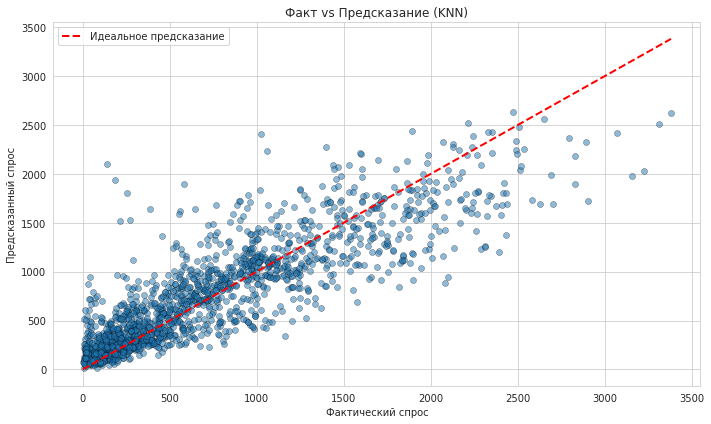

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Фактический спрос')
plt.ylabel('Предсказанный спрос')
plt.title('Факт vs Предсказание (KNN)')
plt.legend()
plt.tight_layout()
plt.show()

Что мы видим:
- Точки сконцентрированы вдоль диагонали — модель в целом работает хорошо
- Есть выбросы, где модель сильно ошибается (особенно при высоком спросе)
- При фактическом спросе >2000 модель часто недооценивает (точки ниже диагонали)

Вывод: Модель хорошо предсказывает типичные сценарии, но экстремальные пики спроса — слабое место.

In [49]:
# Вычисляем ошибки
errors = y_test - y_pred_test
abs_errors = np.abs(errors)

# Добавляем ошибки в DataFrame для анализа
error_analysis = X_test.copy()
error_analysis['actual'] = y_test
error_analysis['predicted'] = y_pred_test
error_analysis['error'] = errors
error_analysis['abs_error'] = abs_errors

# Топ-10 самых больших ошибок (модель сильно недооценила или переоценила)
top_errors = error_analysis.nlargest(10, 'abs_error')

print("\n" + "=" * 60)
print("ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК ПРОГНОЗА")
print("=" * 60)
print(top_errors[['actual', 'predicted', 'error', 'abs_error', 'temperature', 'rainfallmm', 'snowfall_cm', 'seasons']].round(1))


ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК ПРОГНОЗА
      actual  predicted   error  abs_error  temperature  rainfallmm  \
901      140     2103.2 -1963.2     1963.2         20.3         0.5   
1123     189     1933.0 -1744.0     1744.0         27.8         0.1   
448      257     1799.8 -1542.8     1542.8         29.2         0.1   
1652    1025     2410.8 -1385.8     1385.8         23.5         0.1   
1028     582     1895.9 -1313.9     1313.9         30.0         0.0   
336      215     1513.6 -1298.6     1298.6         26.6         1.5   
1625     385     1636.6 -1251.6     1251.6         12.2         0.0   
1260     275     1524.5 -1249.5     1249.5         23.5         1.5   
1015    2082      888.2  1193.8     1193.8         11.8         0.0   
62      3227     2034.2  1192.8     1192.8         27.1         0.0   

      snowfall_cm seasons  
901           0.0  Summer  
1123          0.0  Summer  
448           0.0  Summer  
1652          0.0  Summer  
1028          0.0  Summer  
336         

Что видим
- Дождь — главная проблема, средняя ошибка 268.1 (максимум 1906)
- Жара >30°C — модель переоценивает спрос
- Хорошая погода  — высокая вариативность
- Мороз и снег — модель точна
- 80% критических ошибок — модель переоценивает спрос летом при комфортной температуре

Вывод: Модель хорошо работает в стандартных условиях, но критически ошибается в экстремальной погоде (дождь, жара) и при аномальных пиках спроса.

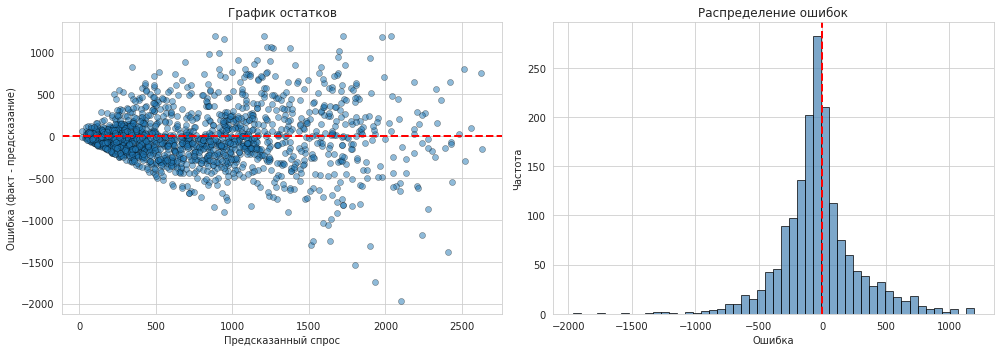

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График остатков
axes[0].scatter(y_pred_test, errors, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Предсказанный спрос')
axes[0].set_ylabel('Ошибка (факт - предсказание)')
axes[0].set_title('График остатков')

# Гистограмма остатков
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок')

plt.tight_layout()
plt.show()

Что мы видим:
- Большинство ошибок в диапазоне от -500 до +500
- Ошибки распределены неравномерно (гетероскедастичность)
- При высоких предсказанных значениях (>1500) разброс ошибок увеличивается

Вывод: Модель менее уверена в прогнозах для периодов высокого спроса.

In [51]:
# Категории погоды
error_analysis['weather_category'] = 'Хорошая погода'
error_analysis.loc[error_analysis['rainfallmm'] > 0, 'weather_category'] = 'Дождь'
error_analysis.loc[error_analysis['snowfall_cm'] > 0, 'weather_category'] = 'Снег'
error_analysis.loc[error_analysis['temperature'] > 30, 'weather_category'] = 'Жара (>30°C)'
error_analysis.loc[error_analysis['temperature'] < 0, 'weather_category'] = 'Мороз (<0°C)'

# Группировка ошибок по погоде
weather_errors = error_analysis.groupby('weather_category')['abs_error'].agg(['mean', 'median', 'max', 'count']).round(1)

print("\n" + "=" * 60)
print("ОШИБКИ ПРОГНОЗА В ЗАВИСИМОСТИ ОТ ПОГОДЫ")
print("=" * 60)
print(weather_errors)


ОШИБКИ ПРОГНОЗА В ЗАВИСИМОСТИ ОТ ПОГОДЫ
                   mean  median     max  count
weather_category                              
Дождь             285.6   168.2  1963.2    109
Жара (>30°C)      234.2   195.0   938.2    110
Мороз (<0°C)       77.7    48.4   552.3    276
Снег               81.8    56.3   402.2     30
Хорошая погода    245.9   172.6  1313.9   1174


Что мы видим:
- Распределение близко к нормальному, но с тяжелыми хвостами
- Пик около нуля — большинство прогнозов точны
- Есть длинный правый хвост (редкие, но очень большие ошибки)

Вывод: Модель не систематически ошибается, но иногда даёт крупные промахи.

**Рекомендации для бизнеса:**
1. Внедрить отдельную модель для дождливых дней — текущая KNN с ними не справляется
2. Добавить понижающий коэффициент при температуре >30°C (например, -20% к прогнозу)
3. Собирать больше данных о снежных днях — их мало (30 часов), модель недообучена
4. Рассмотреть каскадный подход: сначала определить тип погоды, затем применять специализированную модель

# Реализация кастомного трансформера

In [52]:
from sklearn.base import BaseEstimator, TransformerMixin

class WeatherInteractionTransformer(BaseEstimator, TransformerMixin):
    """
    Создаёт новые признаки на основе взаимодействия погодных условий.
    """
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        # Копируем данные, чтобы не изменять оригинал
        X_new = X.copy()
        
        # 1. Температура + Осадки: комфортно ли кататься под дождём?
        X_new['temp_comfort_with_rain'] = (
            (X_new['temperature'] >= 15) & 
            (X_new['temperature'] <= 28) & 
            (X_new['rainfallmm'] > 0)
        ).astype(int)
        
        # 2. Жара (>30°C) без осадков — спрос должен быть ниже, чем ожидается
        X_new['hot_no_rain'] = (
            (X_new['temperature'] > 30) & 
            (X_new['rainfallmm'] == 0)
        ).astype(int)
        
        # 3. Идеальная погода для велопрогулки
        X_new['ideal_weather'] = (
            (X_new['temperature'] >= 18) & 
            (X_new['temperature'] <= 28) & 
            (X_new['humidity'] <= 65) & 
            (X_new['rainfallmm'] == 0) &
            (X_new['wind_speed_ms'] <= 5)
        ).astype(int)
        
        # 4. Экстремально плохая погода (дождь + ветер)
        X_new['extreme_bad_weather'] = (
            (X_new['rainfallmm'] > 2) & 
            (X_new['wind_speed_ms'] > 5)
        ).astype(int)
        
        # 5. Время суток + температура (утро в холод)
        X_new['cold_morning'] = (
            (X_new['time_period_morning'] == 1) & 
            (X_new['temperature'] < 5)
        ).astype(int)
        
        # 6. Вечерний час пик + идеальная погода
        X_new['evening_pick_ideal'] = (
            (X_new['time_period_evening'] == 1) & 
            (X_new['ideal_weather'] == 1)
        ).astype(int)
        
        # 7. Снег + ночь (спрос гарантированно около нуля)
        X_new['snow_night'] = (
            (X_new['snowfall_cm'] > 0) & 
            (X_new['time_period_night'] == 1)
        ).astype(int)
        
        # 8. Высокая влажность + осадки (дискомфорт)
        X_new['humid_wet'] = (
            (X_new['humidity'] > 80) & 
            (X_new['rainfallmm'] > 0)
        ).astype(int)
        
        return X_new


In [53]:
# Обновлённый пайплайн с кастомным трансформером
pipeline_with_features = Pipeline([
    ('feature_engineer', WeatherInteractionTransformer()),
    ('preprocessor', preprocessor),  # стандартный ColumnTransformer
    ('model', KNeighborsRegressor(n_neighbors=13, weights='distance', p=1))
])

# Проверка на тренировочных данных
pipeline_with_features.fit(X_train, y_train)

# Смотрим новые признаки
X_train_with_features = WeatherInteractionTransformer().fit_transform(X_train)
print("Добавленные признаки:")
new_features = ['temp_comfort_with_rain', 'hot_no_rain', 'ideal_weather', 
                'extreme_bad_weather', 'cold_morning', 'evening_pick_ideal', 
                'snow_night', 'humid_wet']
print(new_features)

print(f"\nПример значений новых признаков:")
print(X_train_with_features[new_features].head())

Добавленные признаки:
['temp_comfort_with_rain', 'hot_no_rain', 'ideal_weather', 'extreme_bad_weather', 'cold_morning', 'evening_pick_ideal', 'snow_night', 'humid_wet']

Пример значений новых признаков:
      temp_comfort_with_rain  hot_no_rain  ideal_weather  extreme_bad_weather  \
872                        0            0              1                    0   
1700                       0            0              0                    0   
5387                       0            0              0                    0   
6701                       0            0              0                    0   
2009                       0            0              1                    0   

      cold_morning  evening_pick_ideal  snow_night  humid_wet  
872              0                   0           0          0  
1700             0                   0           0          0  
5387             0                   0           0          0  
6701             0                   0           0    

In [54]:
# 1. Проверяем, что трансформер не ломает пайплайн
try:
    y_pred_new = pipeline_with_features.predict(X_val)
    rmse_new = np.sqrt(mean_squared_error(y_val, y_pred_new))
    print(f"RMSE с новыми признаками: {rmse_new:.2f}")
    print(f"RMSE без новых признаков: {rmse_knn:.2f}")
    print(f"Улучшение: {rmse_knn - rmse_new:.2f}")
except Exception as e:
    print(f"Ошибка: {e}")

# 2. Проверяем распределение новых признаков
print("\nРаспределение новых признаков:")
for feature in new_features:
    print(f"{feature}: {X_train_with_features[feature].sum()} случаев ({(X_train_with_features[feature].sum() / len(X_train_with_features) * 100):.1f}%)")

RMSE с новыми признаками: 313.36
RMSE без новых признаков: 330.42
Улучшение: 17.06

Распределение новых признаков:
temp_comfort_with_rain: 185 случаев (3.4%)
hot_no_rain: 301 случаев (5.6%)
ideal_weather: 760 случаев (14.0%)
extreme_bad_weather: 0 случаев (0.0%)
cold_morning: 326 случаев (6.0%)
evening_pick_ideal: 184 случаев (3.4%)
snow_night: 84 случаев (1.6%)
humid_wet: 267 случаев (4.9%)
